# 🛢️ ProdIQ: Water Cut and BS&W Forecasting Pilot

This notebook presents the development of **ProdIQ**, a pilot machine learning model designed to predict **Water Cut** and **Basic Sediment & Water (BS&W)** — two critical parameters for assessing fluid quality in oilfield production.

The goal of this project is to explore data driven approaches for forecasting these parameters using key production features such as wellhead pressure, choke size, behind casing pressure,Tubing head pressure, Tubing head temperature, pressure downstream choke, and temperature downstream choke  

To identify the most effective model, several regression algorithms were trained and evaluated:
- **XGBoost**, **CatBoost**, **HistGradientBoosting**
- **GradientBoosting**, **ExtraTrees**, **RandomForest**
- **K-Nearest Neighbors (KNN)**
- **Ridge** and **Lasso Regression**

Most ensemble models performed well, achieving high R² scores on the test set, especially XGBoost, CatBoost, and RandomForest. However, **Ridge** and **Lasso** produced the lowest scores, suggesting linear models struggle to capture the complex relationships in the data.

This work serves as a foundational step toward deploying AI for real-time fluid monitoring and production optimization in the oil and gas industry.


In [3]:
#import Python libraries and Machine Learning Frameworks

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import  XGBRegressor
import catboost as cb
import lightgbm as Lgb
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor


In [4]:
#load the dataset
data = pd.read_csv('/content/sample_data/well 297A long string GL Dataset2.csv')

In [5]:
# visualize the first and last  five rows of the dataset
data

,Date / time,"Choke ( 1/64"" )",THP (bar ),THT ( C ),Pressure DS Choke ( bar ),Temperature DS Choke ( C ),CHP ( bar ),CHT ( C ),TAP ( bar ),BCP ( bar ),Bottom press. ( bar ),Bottom temp. ( C ),Water ( % ),Emulsion ( % ),Sand ( % ),BS&W ( % ),H2S ( ppm )
0,6/20/2000 0:00,28,31.0,28,7.5,25,84.0,NaN,117,7.0,NaN,NaN,47.0,0.0,0.01,47.01,0
1,6/20/2000 2:00,28,30.5,28,7.5,25,84.0,NaN,117,7.0,NaN,NaN,44.0,0.0,0.01,44.01,0
2,6/20/2000 4:00,28,30.0,28,7.5,25,84.0,NaN,117,7.0,NaN,NaN,51.0,0.0,0.02,51.02,0
3,6/20/2000 6:00,28,28.5,28,7.5,25,84.0,NaN,117,7.0,NaN,NaN,48.0,0.0,0.02,48.02,0
4,6/20/2000 8:00,28,29.0,28,7.5,25,84.0,NaN,117,7.0,NaN,NaN,51.0,0.0,0.02,51.02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,8/31/2000 14:00,40,24.5,33,7.5,31,80.0,NaN,117,10.0,NaN,NaN,25.0,0.0,0.02,25.02,0
1015,8/31/2000 16:00,40,23.5,33,7.5,32,80.0,NaN,117,10.0,NaN,NaN,20.0,0.0,0.02,20.02,0
1016,8/31/2000 18:00,40,25.0,33,7.5,32,80.0,NaN,117,10.0,NaN,NaN,22.0,0.0,0.02,22.02,0
1017,8/31/2000 20:00,40,26.0,33,7.5,32,80.0,NaN,117,10.0,NaN,NaN,26.0,0.0,0.02,26.02,0


In [6]:
# dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date / time                 1019 non-null   object 
 1   Choke ( 1/64" )             1019 non-null   int64  
 2   THP (bar )                  1019 non-null   float64
 3   THT ( C )                   1019 non-null   int64  
 4   Pressure DS Choke ( bar )   1019 non-null   float64
 5   Temperature DS Choke ( C )  1019 non-null   int64  
 6   CHP ( bar )                 1019 non-null   float64
 7   CHT ( C )                   0 non-null      float64
 8   TAP ( bar )                 1019 non-null   int64  
 9   BCP ( bar )                 1019 non-null   float64
 10  Bottom press. ( bar )       0 non-null      float64
 11  Bottom temp. ( C )          0 non-null      float64
 12  Water ( % )                 1014 non-null   float64
 13  Emulsion ( % )              1014 

In [7]:
#check the missing value
data.isna().sum()

,0
Date / time,0
"Choke ( 1/64"" )",0
THP (bar ),0
THT ( C ),0
Pressure DS Choke ( bar ),0
Temperature DS Choke ( C ),0
CHP ( bar ),0
CHT ( C ),1019
TAP ( bar ),0
BCP ( bar ),0


In [8]:
#see the dataset missing value in percentage
missing_VALUES = data['BS&W ( % )'].isnull().sum() / data['BS&W ( % )'].count() * 100
print(f"Percentage of missing values in 'BS&W': {missing_VALUES:.2f}%")

Percentage of missing values in 'BS&W': 0.49%


In [9]:
# View the statistics of the dataset
data.describe()

,"Choke ( 1/64"" )",THP (bar ),THT ( C ),Pressure DS Choke ( bar ),Temperature DS Choke ( C ),CHP ( bar ),CHT ( C ),TAP ( bar ),BCP ( bar ),Bottom press. ( bar ),Bottom temp. ( C ),Water ( % ),Emulsion ( % ),Sand ( % ),BS&W ( % ),H2S ( ppm )
count,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,0.0,1019.000000,1019.000000,0.0,0.0,1014.000000,1014.0,1014.000000,1014.000000,1019.0
mean,35.400393,26.304220,30.915604,7.556919,28.122669,82.315113,NaN,118.238469,9.883219,NaN,NaN,39.483235,0.0,0.030917,39.514152,0.0
std,4.640160,4.170449,2.104990,0.158885,2.272166,2.036978,NaN,0.883739,0.364973,NaN,NaN,10.728233,0.0,0.020041,10.725687,0.0
min,0.000000,8.000000,28.000000,7.500000,22.000000,79.000000,NaN,117.000000,7.000000,NaN,NaN,8.000000,0.0,0.010000,8.100000,0.0
25%,32.000000,24.000000,28.000000,7.500000,27.000000,80.000000,NaN,117.000000,10.000000,NaN,NaN,30.000000,0.0,0.010000,30.030000,0.0
50%,36.000000,25.000000,32.000000,7.500000,29.000000,82.000000,NaN,119.000000,10.000000,NaN,NaN,41.000000,0.0,0.030000,41.050000,0.0
75%,40.000000,29.000000,33.000000,7.500000,30.000000,84.000000,NaN,119.000000,10.000000,NaN,NaN,49.000000,0.0,0.050000,49.010000,0.0
max,40.000000,41.000000,33.000000,8.000000,33.000000,100.000000,NaN,119.000000,10.000000,NaN,NaN,68.000000,0.0,0.250000,68.010000,0.0


In [10]:
#convert time format into  pd  format
data['Date / time'] = pd.to_datetime(data['Date / time'], format='%d/%m/%Y %H:%M', errors='coerce')


In [11]:
#check the columns in the dataset
print(data.columns)

Index(['Date / time', 'Choke ( 1/64" )', 'THP (bar )', 'THT ( C )',
       'Pressure DS Choke ( bar )', 'Temperature DS Choke ( C )',
       'CHP ( bar )', 'CHT ( C )', 'TAP ( bar )', 'BCP ( bar )',
       'Bottom press. ( bar )', 'Bottom temp. ( C )', 'Water ( % )',
       'Emulsion ( % )', 'Sand  ( % )', 'BS&W ( % )', 'H2S ( ppm )'],
      dtype='object')


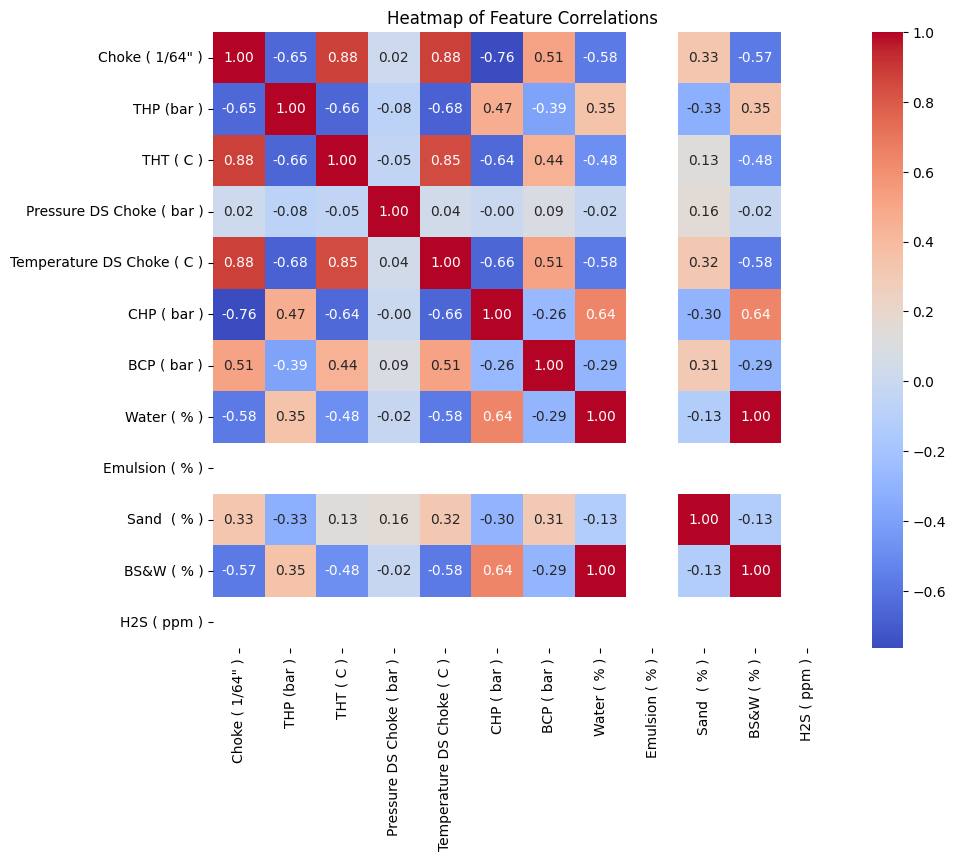

In [12]:
#drop some columns out of the dataset
drop = data.drop(columns=['TAP ( bar )', 'CHT ( C )' , 'Bottom press. ( bar )','Bottom temp. ( C )', 'Date / time'])
rop = drop.replace(' ', np.nan)
rop = drop.apply(pd.to_numeric, errors='coerce')

#handling missing value
impute = SimpleImputer(strategy='mean')
misiing = impute.fit_transform(drop)

# Convert the result back to a DataFrame
drop_filled = pd.DataFrame(misiing, columns=drop.columns)
correlation_matrix = drop_filled.corr()
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Title and display
plt.title("Heatmap of Feature Correlations")
plt.show()


In [13]:
# set  input and output features
X = data.drop(columns=['TAP ( bar )', 'CHT ( C )' , 'Bottom press. ( bar )','Bottom temp. ( C )', 'Date / time', 'Emulsion ( % )','Sand  ( % )', 'H2S ( ppm )', 'BS&W ( % )', 'Water ( % )' ])
Y = data[['BS&W ( % )', 'Water ( % )']]

In [14]:
#view output features
Y

,BS&W ( % ),Water ( % )
0,47.01,47.0
1,44.01,44.0
2,51.02,51.0
3,48.02,48.0
4,51.02,51.0
...,...,...
1014,25.02,25.0
1015,20.02,20.0
1016,22.02,22.0
1017,26.02,26.0


In [15]:
#view missing value in the output
Y.isnull().sum()

,0
BS&W ( % ),5
Water ( % ),5


In [16]:
Y.loc[:, 'BS&W ( % )'] = Y['BS&W ( % )'].fillna(Y['BS&W ( % )'].mean())
Y.loc[:, 'Water ( % )'] = Y['Water ( % )'].fillna(Y['BS&W ( % )'].mean())


In [17]:
#view output feature
X

,"Choke ( 1/64"" )",THP (bar ),THT ( C ),Pressure DS Choke ( bar ),Temperature DS Choke ( C ),CHP ( bar ),BCP ( bar )
0,28,31.0,28,7.5,25,84.0,7.0
1,28,30.5,28,7.5,25,84.0,7.0
2,28,30.0,28,7.5,25,84.0,7.0
3,28,28.5,28,7.5,25,84.0,7.0
4,28,29.0,28,7.5,25,84.0,7.0
...,...,...,...,...,...,...,...
1014,40,24.5,33,7.5,31,80.0,10.0
1015,40,23.5,33,7.5,32,80.0,10.0
1016,40,25.0,33,7.5,32,80.0,10.0
1017,40,26.0,33,7.5,32,80.0,10.0


In [18]:
# split train and test dataset 80% and 20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
# train with xgboost model
xg= XGBRegressor( max_depth = 2000, learning_rate = 0.03, n_estimators=100 )
xg.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2000, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [20]:
#make a prediction
Y_predict_xg = xg.predict(X_test)
Y_predict_xg

array([[46.277584, 46.26287 ],
       [50.86749 , 50.860096],
       [41.521984, 41.48305 ],
       [46.648758, 46.628513],
       [47.72701 , 47.6853  ],
       [48.191227, 48.151875],
       [44.346645, 44.34485 ],
       [23.3328  , 23.330292],
       [47.582752, 47.658333],
       [50.86749 , 50.860096],
       [46.964035, 46.92215 ],
       [49.11918 , 49.10194 ],
       [26.476461, 26.442722],
       [49.549084, 49.54228 ],
       [50.60851 , 50.56816 ],
       [40.45519 , 40.39747 ],
       [47.72701 , 47.6853  ],
       [43.080776, 43.030937],
       [27.340372, 27.308514],
       [27.782866, 27.76868 ],
       [52.29778 , 52.273186],
       [27.836847, 27.812914],
       [40.329018, 40.244495],
       [40.909126, 40.93831 ],
       [47.248913, 47.26718 ],
       [43.321136, 43.27072 ],
       [42.392773, 42.333797],
       [40.9028  , 40.908646],
       [27.973719, 27.914692],
       [52.426785, 52.41875 ],
       [27.836847, 27.812914],
       [42.136726, 42.099743],
       [

In [21]:
#evaluate the model
r2 = r2_score(Y_test, Y_predict_xg)
print(f"R2 Score: {r2}")
MSE = mean_squared_error(Y_test, Y_predict_xg)
print(f"Mean Squared Error: {MSE}")
MAE = mean_absolute_error(Y_test, Y_predict_xg)
print(f"Mean Absolute Error: {MAE}")


R2 Score: 0.7767706513404846
Mean Squared Error: 25.494001388549805
Mean Absolute Error: 3.908888339996338


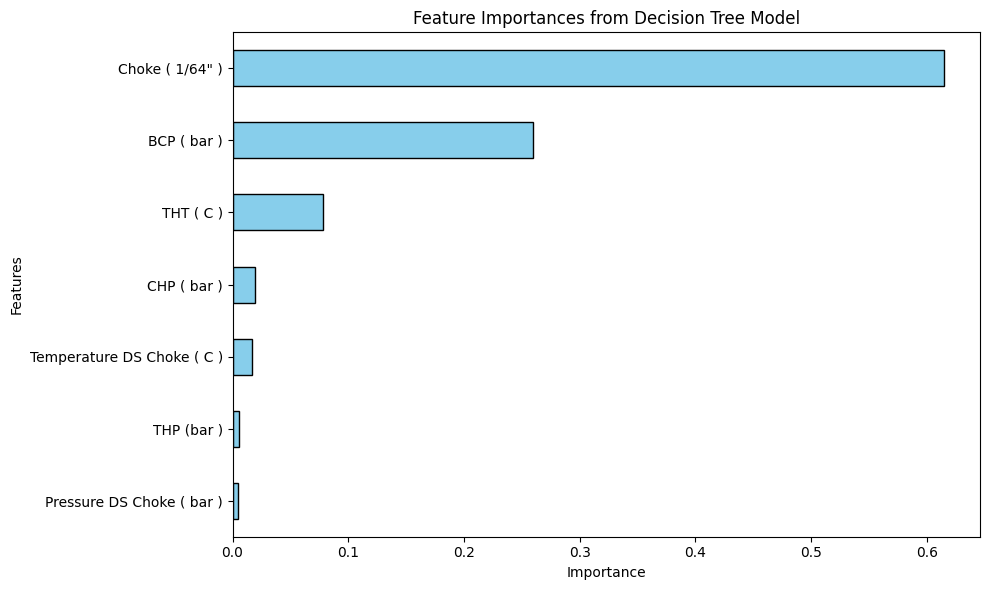

In [22]:
#plot feature importance

model_ranks = pd.Series(xg.feature_importances_,
                        index=X.columns,
                        name="Importance").sort_values(ascending=True)

# Plotting
ax = model_ranks.plot(kind="barh", figsize=(10, 6), color="skyblue", edgecolor="black")
ax.set_title("Feature Importances from Decision Tree Model")
ax.set_xlabel("Importance")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()


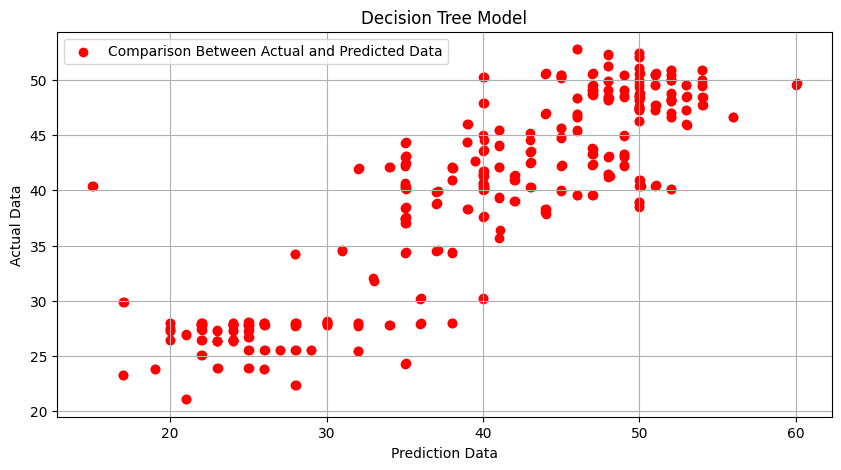

In [23]:
#comparison between actual and predicted data
plt.figure(figsize = (10,5))
plt.scatter(Y_test, Y_predict_xg, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title("Decision Tree Model")
plt.xlabel("Prediction Data")
plt.ylabel("Actual Data")
plt.show()

In [24]:
 #train histGradientboost model

multioutput_model = MultiOutputRegressor(HistGradientBoostingRegressor())
multioutput_model.fit(X_train, Y_train)


MultiOutputRegressor(estimator=HistGradientBoostingRegressor())

In [25]:
#make prediction
hist_predict = multioutput_model.predict(X_test)
hist_predict

array([[46.35751828, 46.1476454 ],
       [51.74667136, 51.77149329],
       [41.11626999, 40.94415195],
       [46.01385102, 46.03668826],
       [48.30021941, 48.16556904],
       [46.57400063, 46.76400202],
       [43.85084034, 44.13169353],
       [26.87175474, 26.43306913],
       [49.38858654, 49.24301946],
       [51.74667136, 51.77149329],
       [45.67196524, 45.92272797],
       [48.98253417, 49.06678043],
       [25.91463805, 25.95010725],
       [50.88446443, 50.79307045],
       [51.9054727 , 51.98862892],
       [44.16919572, 43.86916423],
       [48.30021941, 48.16556904],
       [43.26110464, 43.20629015],
       [26.671666  , 26.63717025],
       [26.93948128, 26.91737338],
       [52.4855176 , 52.40135479],
       [27.14141158, 27.10552579],
       [41.0523521 , 41.19906035],
       [37.67100808, 37.95777906],
       [45.88411275, 45.92476016],
       [42.85058206, 42.90151537],
       [41.84362893, 41.75420255],
       [39.87443953, 39.62986821],
       [27.53444171,

In [26]:
# evaluate the model
r2 = r2_score(Y_test, hist_predict)
print(f"R2 Score: {r2}")
MSE = mean_squared_error(Y_test, hist_predict)
print(f"Mean Squared Error: {MSE}")
MAE = mean_absolute_error(Y_test, hist_predict)
print(f"Mean Absolute Error: {MAE}")

R2 Score: 0.7730061101693834
Mean Squared Error: 25.923912717075154
Mean Absolute Error: 3.8209519957586426


In [27]:
# train Random forest model
RF = RandomForestRegressor(max_depth=1500,  )
RF.fit(X_train, Y_train)

RandomForestRegressor(max_depth=1500)

In [28]:
#make prediction
Rf_predict = RF.predict(X_test)
Rf_predict

array([[47.41694019, 47.40634019],
       [51.24087901, 51.23087901],
       [41.78824068, 41.74886099],
       [46.46948976, 46.45633333],
       [47.903769  , 47.86073593],
       [48.50774167, 48.46566667],
       [44.56577417, 44.54025   ],
       [21.9694    , 21.95      ],
       [47.40440476, 47.39440476],
       [51.24087901, 51.23087901],
       [47.27801397, 47.23455556],
       [49.9365781 , 49.92645238],
       [25.72628117, 25.69609326],
       [50.13461905, 50.12461905],
       [51.84634538, 51.80189755],
       [41.00754357, 40.95894048],
       [47.903769  , 47.86073593],
       [43.10164699, 43.05164699],
       [26.56261269, 26.53044584],
       [27.01639099, 26.9875176 ],
       [53.56151976, 53.55151976],
       [27.30521461, 27.27624945],
       [41.2522    , 41.21      ],
       [39.47495833, 39.41583333],
       [47.21414286, 47.19914286],
       [43.75443684, 43.70443684],
       [41.9278    , 41.88      ],
       [40.7514    , 40.66566667],
       [27.66830042,

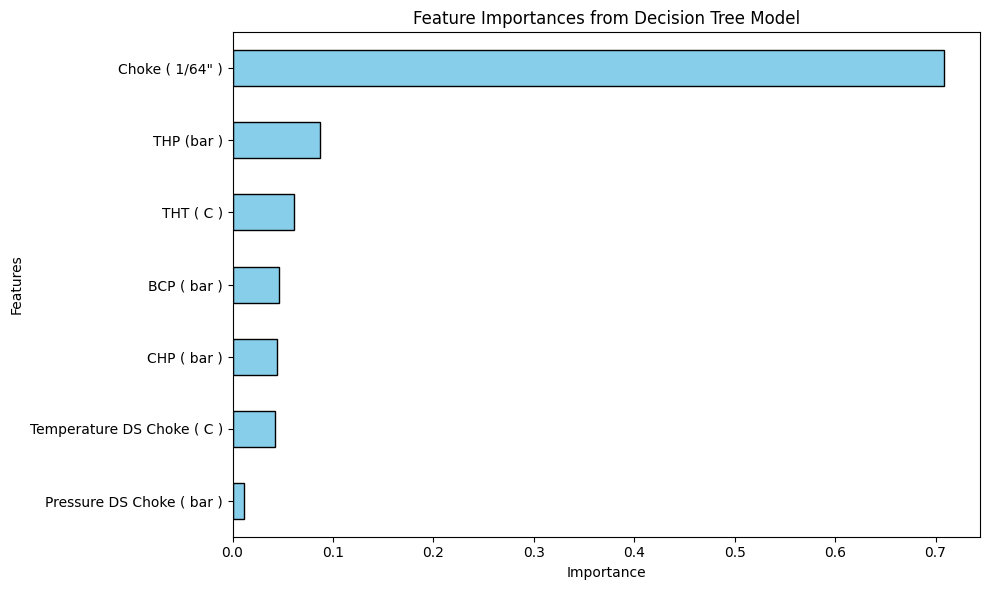

In [29]:
#plot features importance
model_ranks = pd.Series(RF.feature_importances_,
                        index=X.columns,
                        name="Importance").sort_values(ascending=True)

# Plotting
ax = model_ranks.plot(kind="barh", figsize=(10, 6), color="skyblue", edgecolor="black")
ax.set_title("Feature Importances from Decision Tree Model")
ax.set_xlabel("Importance")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()

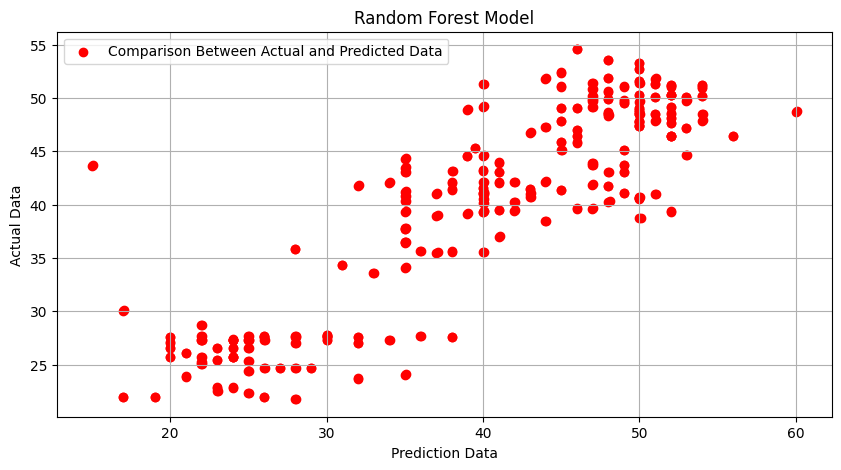

In [30]:
# comparison between actual and predicted data
plt.figure(figsize = (10,5))
plt.scatter(Y_test, Rf_predict, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title("Random Forest Model")
plt.xlabel("Prediction Data")
plt.ylabel("Actual Data")
plt.show()

In [31]:
#evaluate the model
r2 = r2_score(Y_test, Rf_predict)
print(f"R2 Score: {r2}")
MSE = mean_squared_error(Y_test, Rf_predict)
print(f"Mean Squared Error: {MSE}")
MAE = mean_absolute_error(Y_test, Rf_predict)
print(f"Mean Absolute Error: {MAE}")

R2 Score: 0.7680528332621592
Mean Squared Error: 26.489623570689368
Mean Absolute Error: 3.887916274014345


In [33]:
#train ExtraTrees model
XTR = ExtraTreesRegressor(max_depth=3000,  )
XTR.fit(X_train, Y_train)

ExtraTreesRegressor(max_depth=3000)

In [34]:
#makw prediction
XTR_predict = XTR.predict(X_test)
XTR_predict

array([[46.94834286, 46.93714286],
       [51.43857143, 51.42857143],
       [41.665     , 41.625     ],
       [46.68      , 46.66666667],
       [47.9175    , 47.875     ],
       [50.04      , 50.        ],
       [45.02333333, 45.        ],
       [19.1504    , 19.14      ],
       [46.89      , 46.88      ],
       [51.43857143, 51.42857143],
       [47.37666667, 47.33333333],
       [50.01      , 50.        ],
       [25.74428571, 25.71428571],
       [50.208     , 50.198     ],
       [51.644     , 51.6       ],
       [40.55      , 40.5       ],
       [47.9175    , 47.875     ],
       [43.175     , 43.125     ],
       [26.67535714, 26.64285714],
       [27.0726087 , 27.04347826],
       [53.67666667, 53.66666667],
       [27.25974359, 27.23076923],
       [41.8682    , 41.82      ],
       [40.9418    , 40.87      ],
       [47.65796667, 47.64666667],
       [43.71666667, 43.66666667],
       [42.5036    , 42.46      ],
       [41.69646667, 41.61666667],
       [27.65285714,

In [35]:
#evaluate the model
r2 = r2_score(Y_test, XTR_predict)
print(f"R2 Score: {r2}")
MSE = mean_squared_error(Y_test, XTR_predict)
print(f"Mean Squared Error: {MSE}")
MAE = mean_absolute_error(Y_test, XTR_predict)
print(f"Mean Absolute Error: {MAE}")

R2 Score: 0.7707561959168452
Mean Squared Error: 26.180884842658273
Mean Absolute Error: 3.9785974325704916


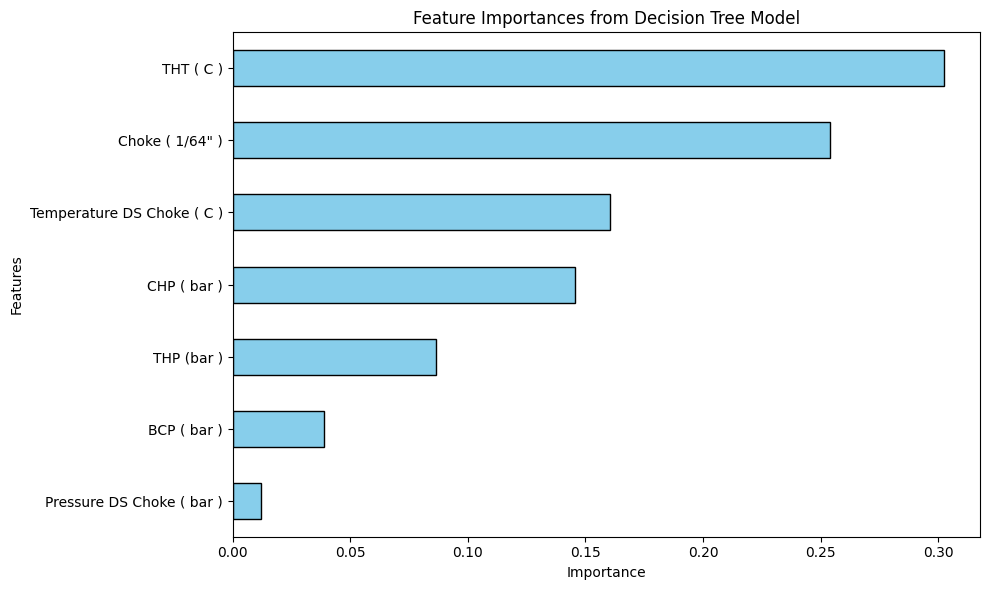

In [36]:
#plot features importance
model_ranks = pd.Series(XTR.feature_importances_,
                        index=X.columns,
                        name="Importance").sort_values(ascending=True)

# Plotting
ax = model_ranks.plot(kind="barh", figsize=(10, 6), color="skyblue", edgecolor="black")
ax.set_title("Feature Importances from Decision Tree Model")
ax.set_xlabel("Importance")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()


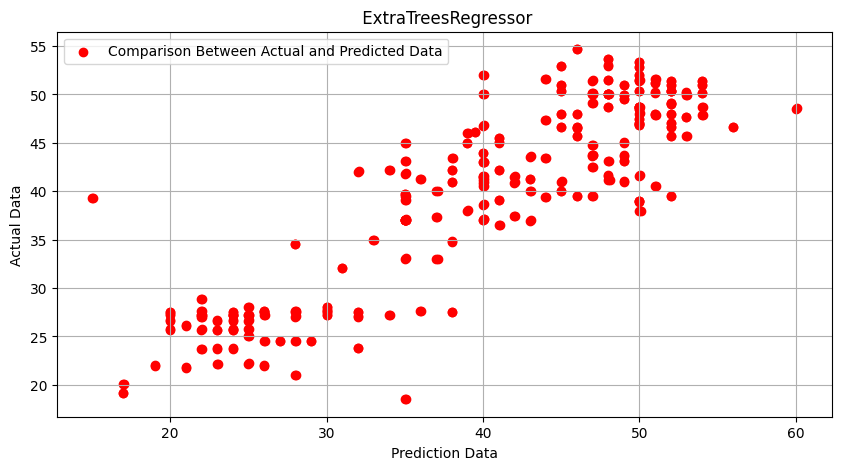

In [37]:
##comparison between actual and predicted data
plt.figure(figsize = (10,5))
plt.scatter(Y_test, XTR_predict, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title(" ExtraTreesRegressor")
plt.xlabel("Prediction Data")
plt.ylabel("Actual Data")
plt.show()

In [38]:
#train Ridge model
RE = Ridge()
RE.fit(X_train, Y_train)

Ridge()

In [39]:
#make Prediction
RE_predict = RE.predict(X_test)
RE_predict

array([[45.33538478, 45.30753573],
       [45.00713995, 44.98618473],
       [40.50434672, 40.47741062],
       [47.01899436, 47.00018515],
       [37.36432852, 37.33237964],
       [35.79688826, 35.76066879],
       [40.19251645, 40.16712204],
       [32.71125756, 32.66931386],
       [44.82789356, 44.80789714],
       [45.00713995, 44.98618473],
       [35.90083168, 35.86409832],
       [46.91505093, 46.89675562],
       [32.04394942, 32.0074062 ],
       [48.89826488, 48.88218458],
       [37.67615879, 37.64266822],
       [33.08607035, 33.05123314],
       [37.36432852, 37.33237964],
       [33.29395719, 33.25809219],
       [31.940006  , 31.90397668],
       [31.62817573, 31.5936881 ],
       [50.98542226, 50.97104307],
       [31.83606258, 31.80054715],
       [38.40091967, 38.35345089],
       [36.86393406, 36.81089943],
       [47.9258447 , 47.90247943],
       [33.39790062, 33.36152172],
       [37.61026075, 37.5698329 ],
       [34.0655873 , 34.00909668],
       [31.73211915,

In [40]:
#evaluate the model
r2 = r2_score(Y_test, RE_predict)
print(f'R2 Score: {r2}')
MSE = mean_squared_error(Y_test, RE_predict)
print(f'Mean Squared Error: {MSE}')
MAE = mean_absolute_error(Y_test, RE_predict)
print(f'Mean Absolute Error: {MAE}')

R2 Score: 0.4673721091380479
Mean Squared Error: 60.82898954473459
Mean Absolute Error: 6.075027842816348


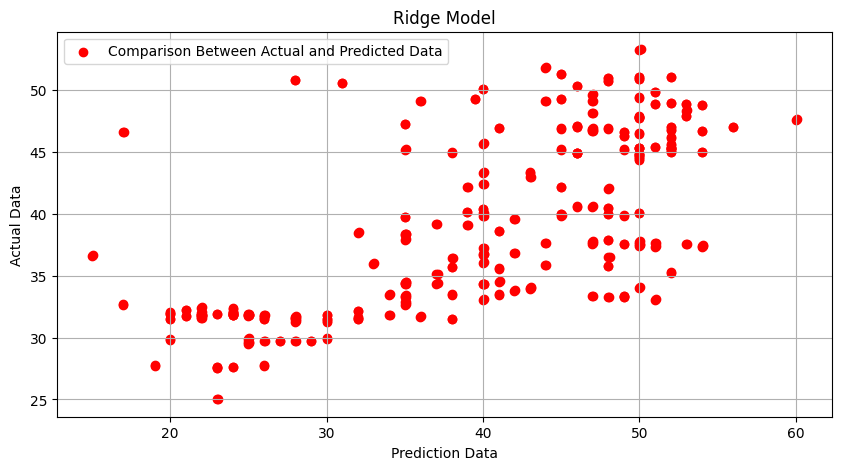

In [41]:
##comparison between actual and predicted data
plt.figure(figsize =(10,5))
plt.scatter(Y_test, RE_predict, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title("Ridge Model")
plt.xlabel("Prediction Data")
plt.ylabel("Actual Data")
plt.show()

In [42]:
#train lasso model
LE = Lasso(alpha=10)
LE.fit(X_train, Y_train)


Lasso(alpha=10)

In [43]:
#make prediction
LE_predixt = LE.predict(X_test)
LE_predixt

array([[38.97220506, 38.94063778],
       [38.97220506, 38.94063778],
       [38.97220506, 38.94063778],
       [45.82324482, 45.80443695],
       [37.25944512, 37.22468798],
       [37.25944512, 37.22468798],
       [38.97220506, 38.94063778],
       [35.54668518, 35.50873819],
       [45.82324482, 45.80443695],
       [38.97220506, 38.94063778],
       [37.25944512, 37.22468798],
       [45.82324482, 45.80443695],
       [35.54668518, 35.50873819],
       [45.82324482, 45.80443695],
       [37.25944512, 37.22468798],
       [37.25944512, 37.22468798],
       [37.25944512, 37.22468798],
       [37.25944512, 37.22468798],
       [35.54668518, 35.50873819],
       [35.54668518, 35.50873819],
       [45.82324482, 45.80443695],
       [35.54668518, 35.50873819],
       [42.39772494, 42.37253736],
       [40.684965  , 40.65658757],
       [38.97220506, 38.94063778],
       [37.25944512, 37.22468798],
       [38.97220506, 38.94063778],
       [40.684965  , 40.65658757],
       [35.54668518,

In [44]:
#evaluate the model
r2 = r2_score(Y_test, LE_predixt)
print(f'R2 Score: {r2}')
MSE = mean_squared_error(Y_test, LE_predixt)
print(f'Mean Squared Error: {MSE}')
MAE = mean_absolute_error(Y_test, LE_predixt)
print(f'Mean Absolute Error: {MAE}')

R2 Score: 0.27457632578026075
Mean Squared Error: 82.84731461638927
Mean Absolute Error: 7.602341949366691


<function matplotlib.pyplot.show(close=None, block=None)>

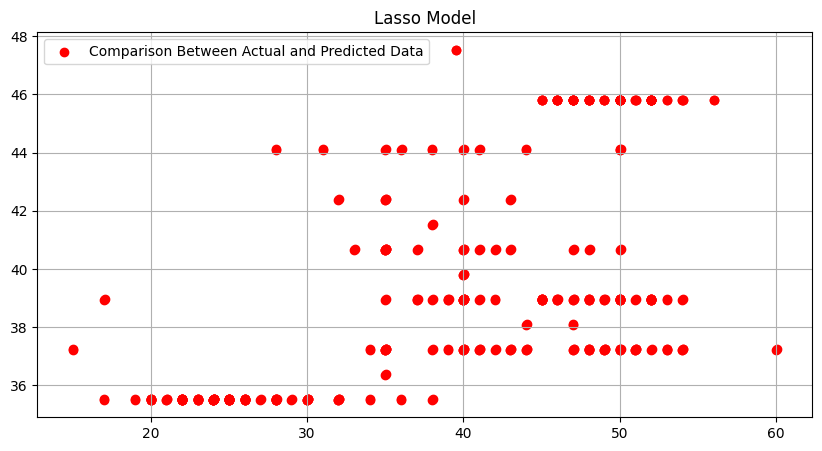

In [45]:
##comparison between actual and predicted data
plt.figure(figsize=(10,5))
plt.scatter(Y_test, LE_predixt, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title("Lasso Model")
plt.show

In [46]:
#train KNN model
KNN = KNeighborsRegressor(n_neighbors=5)
KNN.fit(X_train, Y_train)

KNeighborsRegressor()

In [47]:
#make prediction
KNN_predict = KNN.predict(X_test)
KNN_predict

array([[50.21      , 50.2       ],
       [50.81      , 50.8       ],
       [40.838     , 40.8       ],
       [47.214     , 47.2       ],
       [47.846     , 47.8       ],
       [46.64      , 46.6       ],
       [45.224     , 45.2       ],
       [25.424     , 25.4       ],
       [46.01      , 46.        ],
       [50.81      , 50.8       ],
       [48.644     , 48.6       ],
       [50.41      , 50.4       ],
       [27.632     , 27.6       ],
       [50.21      , 50.2       ],
       [51.644     , 51.6       ],
       [43.45      , 43.4       ],
       [47.846     , 47.8       ],
       [42.25      , 42.2       ],
       [27.232     , 27.2       ],
       [26.828     , 26.8       ],
       [53.01      , 53.        ],
       [28.63      , 28.6       ],
       [43.046     , 43.        ],
       [38.264     , 38.2       ],
       [46.41      , 46.4       ],
       [45.45      , 45.4       ],
       [41.048     , 41.        ],
       [40.696     , 40.6       ],
       [27.832     ,

In [48]:
#evaluate the model
r2 = r2_score(Y_test, KNN_predict)
print(f'R2 Score: {r2}')
MSE = mean_squared_error(Y_test, KNN_predict)
print(f'Mean Squared Error: {MSE}')
MAE = mean_absolute_error(Y_test, KNN_predict)
print(f'Mean Absolute Error: {MAE}')

R2 Score: 0.7685090914072963
Mean Squared Error: 26.437516846756104
Mean Absolute Error: 3.8813897493908778


Text(0.5, 1.0, 'KNeighborsRegressor Model')

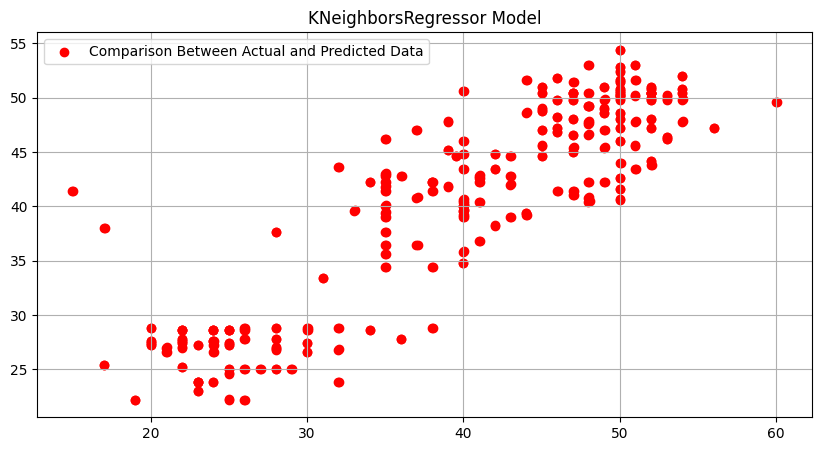

In [50]:
##comparison between actual and predicted data
plt.figure(figsize=(10,5))
plt.scatter(Y_test, KNN_predict, color = "red", label = "Comparison Between Actual and Predicted Data")
plt.legend()
plt.grid()
plt.title("KNeighborsRegressor Model")
